# 03 · 模型解释 · 校准 · 决策曲线 · 敏感性分析

1. **SHAP**:全局重要性 + 依赖图 + 个例 waterfall(选最佳模型)
2. **校准曲线 + Brier**:原始 vs Platt / Isotonic 重校准
3. **DCA(决策曲线分析)**:净获益对比模型 vs treat-all / treat-none
4. **敏感性分析**:特征集 A (baseline-only) vs B (baseline + Δ),验证随访期实验室增量是否带来提升

In [1]:
import os, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RNG = 42
OUT_DIR = 'results'; os.makedirs(OUT_DIR, exist_ok=True)
MODEL_DIR = 'models'
print('OK')

OK


## 1. 加载预处理数据 + 已训练模型

In [2]:
DATA_DIR = 'processed/A_baseline'
X_train = pd.read_parquet(f'{DATA_DIR}/X_train.parquet')
X_val   = pd.read_parquet(f'{DATA_DIR}/X_val.parquet')
X_test  = pd.read_parquet(f'{DATA_DIR}/X_test.parquet')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_val   = np.load(f'{DATA_DIR}/y_val.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

best = joblib.load(f'{MODEL_DIR}/best_model.joblib')
best_name, best_model, best_thr = best['name'], best['model'], best['threshold']
print(f'最佳模型: {best_name}  (Val Youden 阈值 = {best_thr:.4f})')
p_test = best_model.predict_proba(X_test)[:, 1]
print(f'Test  AUROC = {roc_auc_score(y_test, p_test):.4f}'
      f'   AUPRC = {average_precision_score(y_test, p_test):.4f}'
      f'   Brier = {brier_score_loss(y_test, p_test):.4f}')

最佳模型: LightGBM  (Val Youden 阈值 = 0.0098)
Test  AUROC = 0.6609   AUPRC = 0.3035   Brier = 0.1371


## 2. SHAP — 全局特征重要性

SHAP shape: (449, 91)


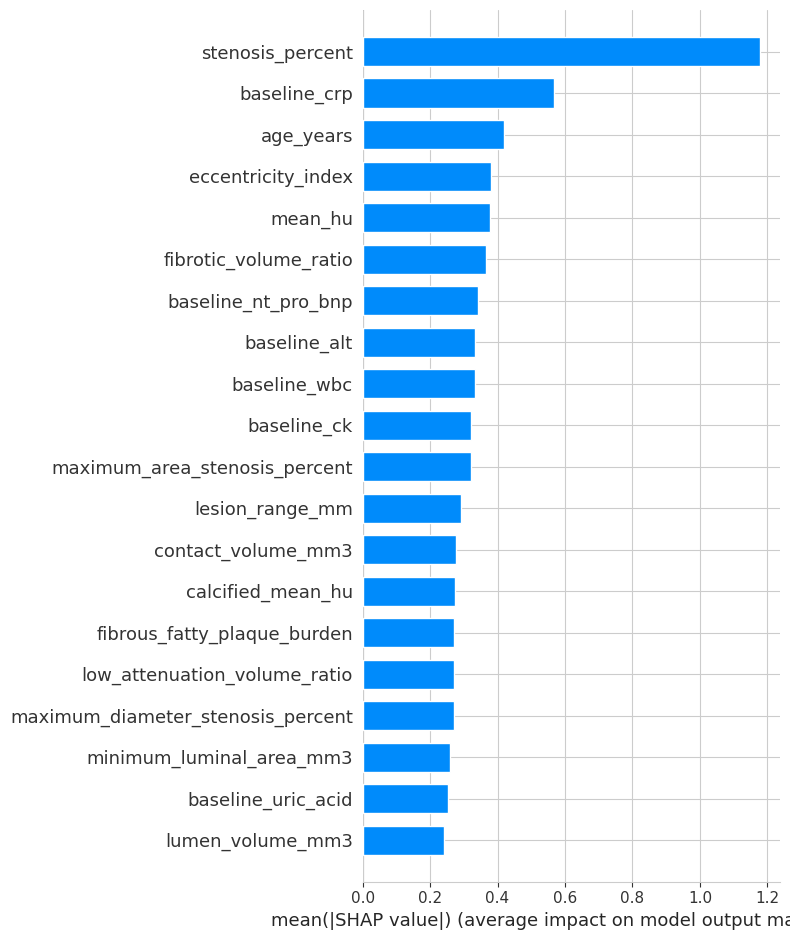

In [3]:
if best_name in ('XGBoost', 'LightGBM', 'RandomForest'):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        sv = shap_values[1]
    elif shap_values.ndim == 3:
        sv = shap_values[..., 1]
    else:
        sv = shap_values
else:
    explainer = shap.LinearExplainer(best_model, X_train)
    sv = explainer.shap_values(X_test)

print('SHAP shape:', sv.shape)
shap.summary_plot(sv, X_test, plot_type='bar', max_display=20, show=False)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/shap_top20_bar.png', dpi=150, bbox_inches='tight'); plt.show()

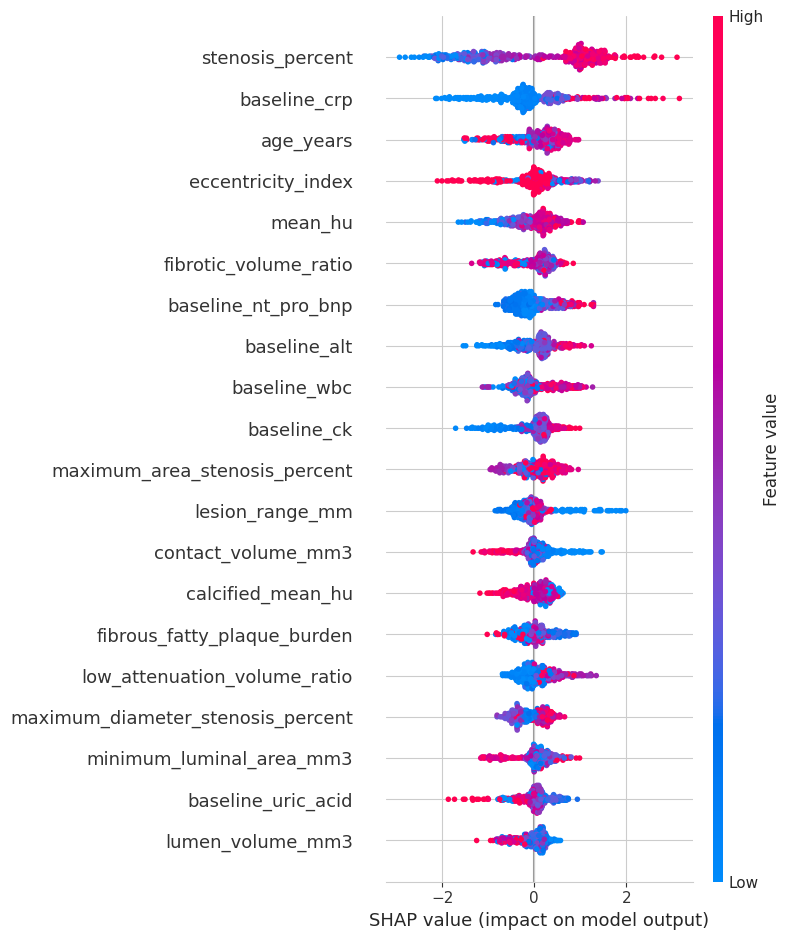

In [4]:
shap.summary_plot(sv, X_test, max_display=20, show=False)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/shap_top20_beeswarm.png', dpi=150, bbox_inches='tight'); plt.show()

In [5]:
mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=X_test.columns).sort_values(ascending=False)
mean_abs.head(20).to_csv(f'{OUT_DIR}/shap_top20_features.csv')
mean_abs.head(20)

stenosis_percent                     1.178607
baseline_crp                         0.566675
age_years                            0.420064
eccentricity_index                   0.381588
mean_hu                              0.377021
fibrotic_volume_ratio                0.366017
baseline_nt_pro_bnp                  0.341456
baseline_alt                         0.333248
baseline_wbc                         0.332872
baseline_ck                          0.321398
maximum_area_stenosis_percent        0.320794
lesion_range_mm                      0.291406
contact_volume_mm3                   0.276018
calcified_mean_hu                    0.274150
fibrous_fatty_plaque_burden          0.271420
low_attenuation_volume_ratio         0.269954
maximum_diameter_stenosis_percent    0.269667
minimum_luminal_area_mm3             0.260002
baseline_uric_acid                   0.253441
lumen_volume_mm3                     0.240446
dtype: float64

## 3. SHAP — 依赖图(Top-6 特征)

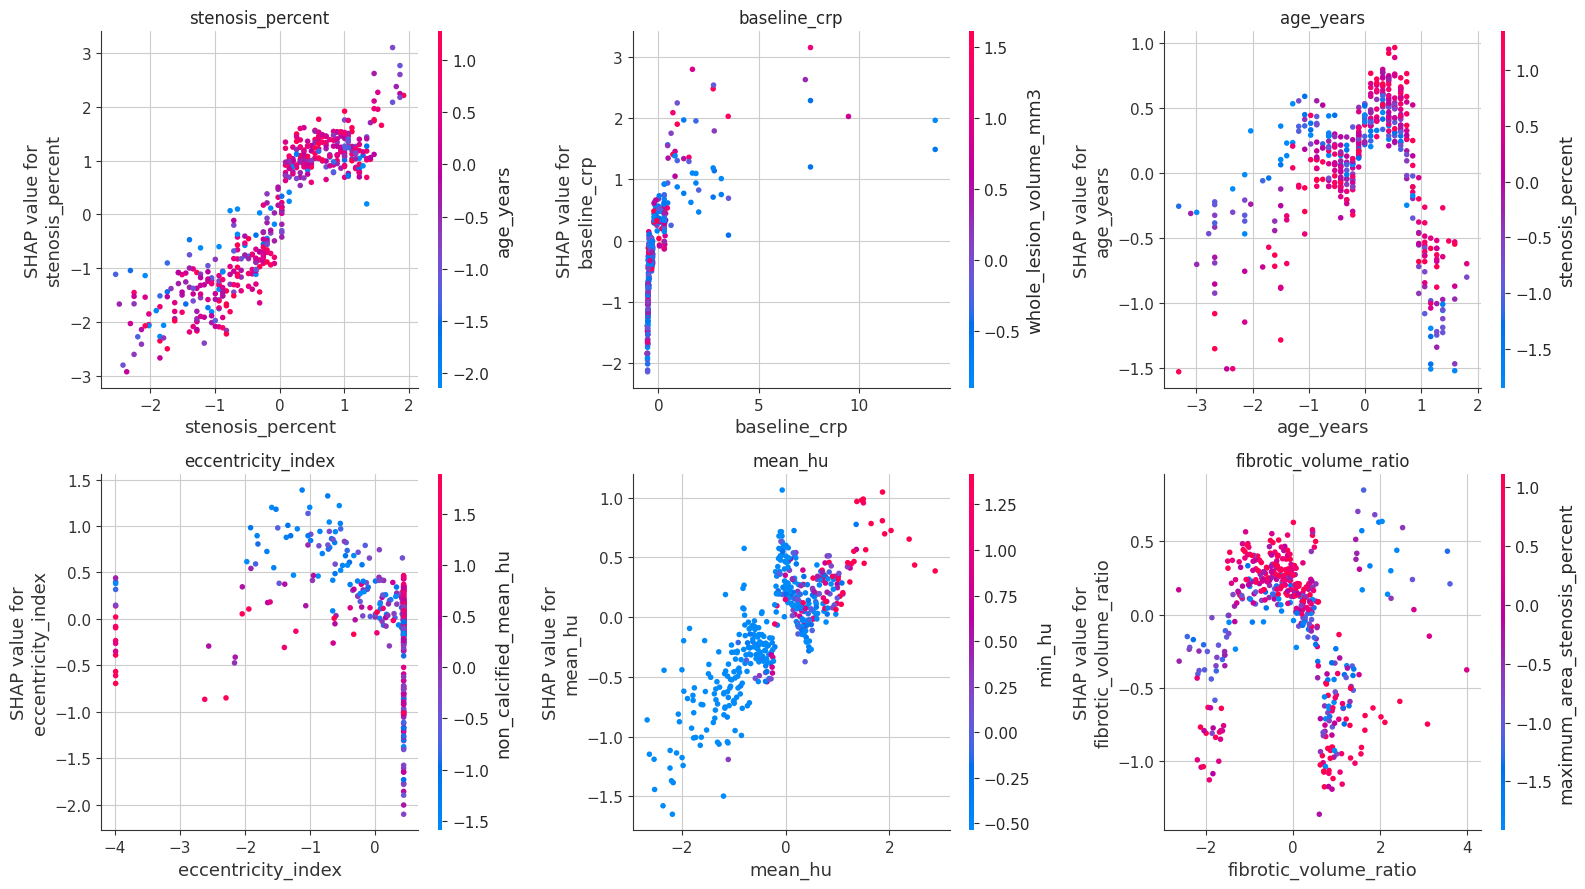

In [6]:
top_features = mean_abs.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, f in zip(axes.flat, top_features):
    shap.dependence_plot(f, sv, X_test, ax=ax, show=False, interaction_index='auto')
    ax.set_title(f)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/shap_dependence_top6.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. SHAP — 个例解释(随机选 1 阳性 + 1 阴性)

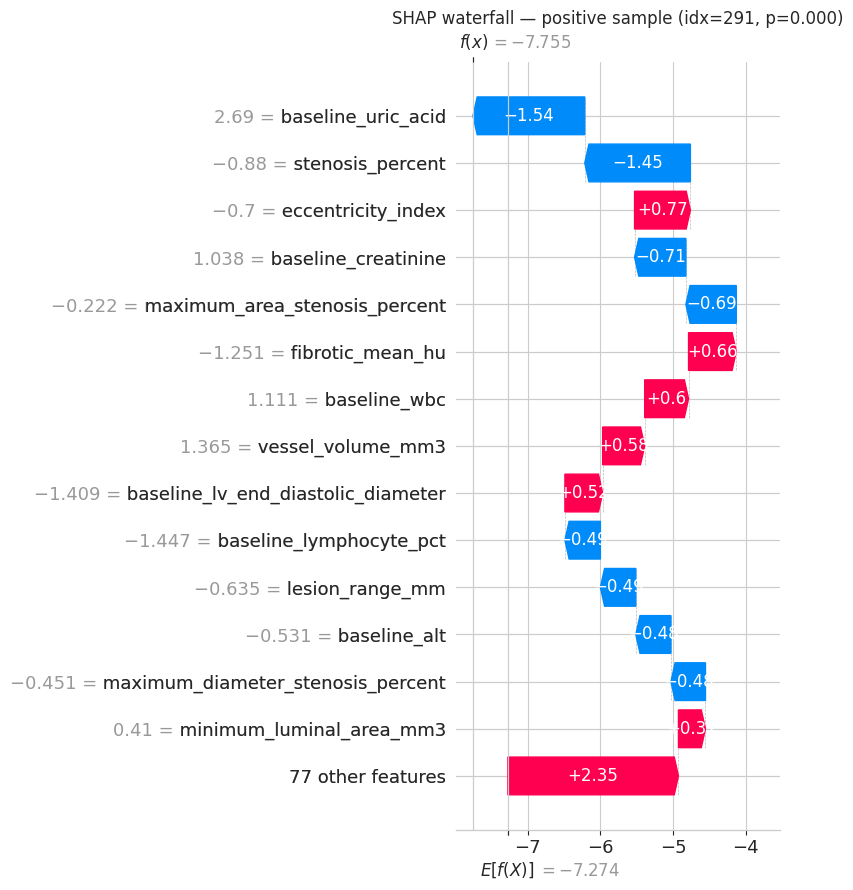

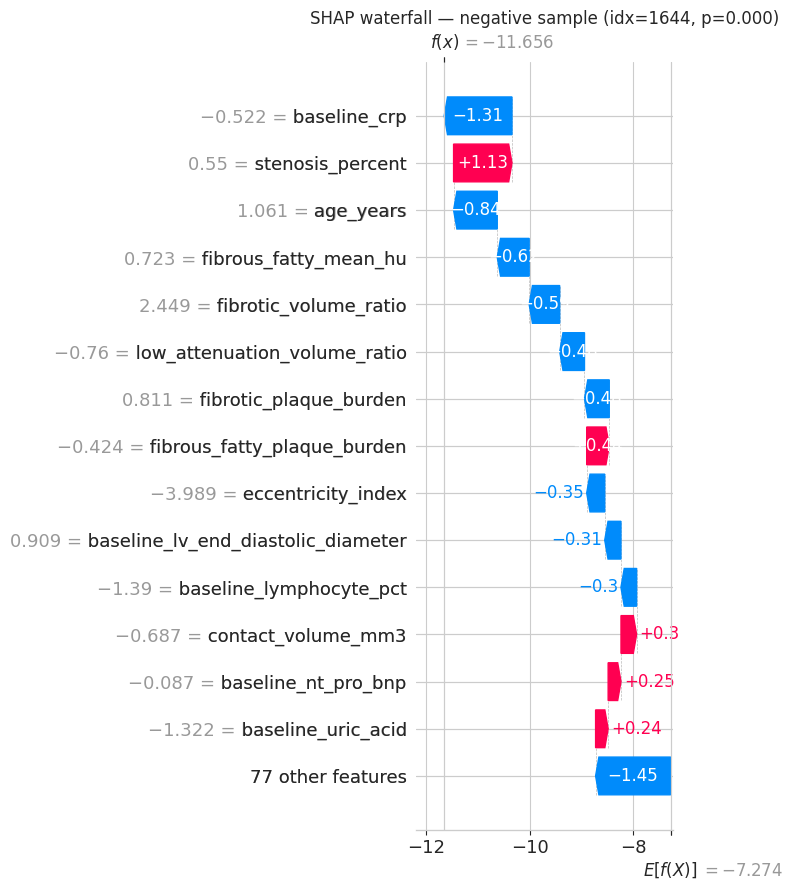

In [7]:
rng = np.random.default_rng(RNG)
pos_loc = rng.choice(np.where(y_test == 1)[0])
neg_loc = rng.choice(np.where(y_test == 0)[0])

ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    ev_arr = np.atleast_1d(ev)
    base_val = ev_arr[1] if ev_arr.size > 1 else ev_arr[0]
else:
    base_val = ev

for label, loc in [('positive', pos_loc), ('negative', neg_loc)]:
    explanation = shap.Explanation(values=sv[loc], base_values=base_val,
                                    data=X_test.iloc[loc].values,
                                    feature_names=X_test.columns.tolist())
    fig = plt.figure(figsize=(9, 6))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f'SHAP waterfall — {label} sample (idx={X_test.index[loc]}, p={p_test[loc]:.3f})')
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/shap_waterfall_{label}.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. 校准曲线 + 重校准 (Platt / Isotonic)

Raw        Brier=0.1371   AUROC=0.6609   AUPRC=0.3035
Platt      Brier=0.1246   AUROC=0.6609   AUPRC=0.3035
Isotonic   Brier=0.1229   AUROC=0.6274   AUPRC=0.2259


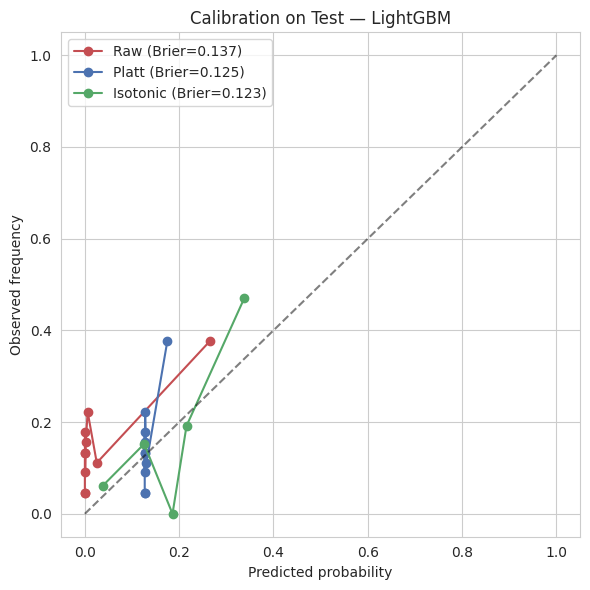

In [8]:
# 用 Val 做重校准,避免污染 Test
p_val_raw  = best_model.predict_proba(X_val)[:, 1]
p_test_raw = best_model.predict_proba(X_test)[:, 1]

# Platt scaling: 用一元 LR 把 raw prob 映射到 calibrated prob
platt = LogisticRegression(max_iter=2000)
platt.fit(p_val_raw.reshape(-1, 1), y_val)
p_test_platt = platt.predict_proba(p_test_raw.reshape(-1, 1))[:, 1]

# Isotonic
from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_val_raw, y_val)
p_test_iso = iso.transform(p_test_raw)

for name, p in [('Raw', p_test_raw), ('Platt', p_test_platt), ('Isotonic', p_test_iso)]:
    print(f'{name:9s}  Brier={brier_score_loss(y_test, p):.4f}'
          f'   AUROC={roc_auc_score(y_test, p):.4f}'
          f'   AUPRC={average_precision_score(y_test, p):.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
for label, p, c in [('Raw', p_test_raw, '#C44E52'),
                    ('Platt', p_test_platt, '#4C72B0'),
                    ('Isotonic', p_test_iso, '#55A868')]:
    pt, pp = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    ax.plot(pp, pt, 'o-', color=c, label=f'{label} (Brier={brier_score_loss(y_test, p):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=.5)
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title(f'Calibration on Test — {best_name}')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/calibration.png', dpi=150, bbox_inches='tight'); plt.show()

## 6. Decision Curve Analysis (DCA)
净获益 = TP/N − FP/N · pt/(1-pt),其中 pt 是阈值概率。

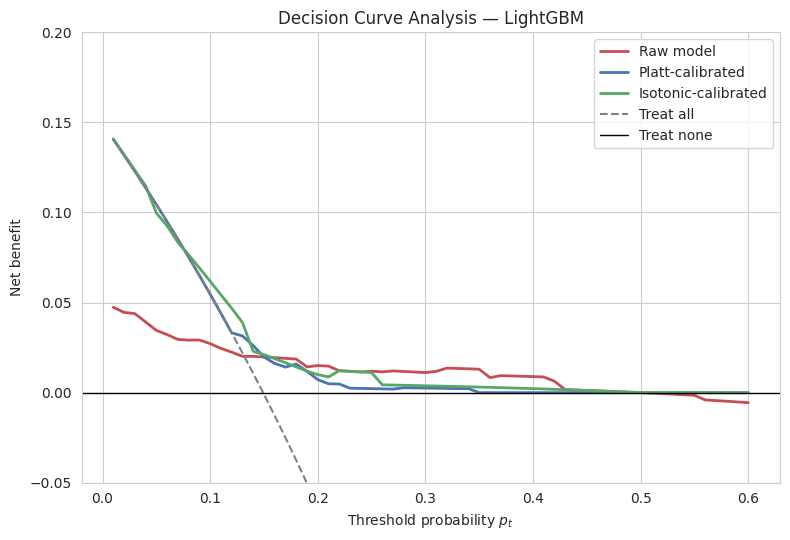

In [9]:
def net_benefit(y_true, y_score, thresh):
    n = len(y_true)
    nb = []
    for pt in thresh:
        pred = (y_score >= pt).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        if pt >= 1:
            nb.append(0); continue
        nb.append(tp/n - fp/n * (pt / (1 - pt)))
    return np.array(nb)

thresh = np.linspace(0.01, 0.6, 60)
prev = y_test.mean()
nb_all = prev - (1 - prev) * (thresh / (1 - thresh))

fig, ax = plt.subplots(figsize=(8, 5.5))
for name, p, c in [('Raw model', p_test_raw, '#C44E52'),
                   ('Platt-calibrated', p_test_platt, '#4C72B0'),
                   ('Isotonic-calibrated', p_test_iso, '#55A868')]:
    nb = net_benefit(y_test, p, thresh)
    ax.plot(thresh, nb, label=name, color=c, lw=2)

ax.plot(thresh, nb_all, '--', color='gray', label='Treat all', lw=1.5)
ax.axhline(0, color='black', lw=1, label='Treat none')
ax.set_xlabel('Threshold probability $p_t$')
ax.set_ylabel('Net benefit')
ax.set_title(f'Decision Curve Analysis — {best_name}')
ax.set_ylim(-0.05, max(nb_all.max(), 0.2))
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/dca.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. 敏感性分析:特征集 A vs B
**问题**:用 baseline + Δ(随访 - 基线)能比 baseline-only 提升多少?
**方法**:同一组超参与同一种模型(LightGBM)在 A、B 两套数据上各训练一次,比较 AUROC/AUPRC。

In [10]:
with open(f'{OUT_DIR}/best_params.json') as f:
    best_params = json.load(f)

lgb_params = best_params['lgb']
rows = []
for fset in ['A_baseline', 'B_baseline_delta']:
    Xtr = pd.read_parquet(f'processed/{fset}/X_train.parquet')
    Xv  = pd.read_parquet(f'processed/{fset}/X_val.parquet')
    Xte = pd.read_parquet(f'processed/{fset}/X_test.parquet')
    ytr = np.load(f'processed/{fset}/y_train.npy')
    yv  = np.load(f'processed/{fset}/y_val.npy')
    yte = np.load(f'processed/{fset}/y_test.npy')
    spw = (ytr == 0).sum() / (ytr == 1).sum()
    m = lgb.LGBMClassifier(**lgb_params, scale_pos_weight=spw,
                           objective='binary', n_jobs=-1,
                           random_state=RNG, verbose=-1).fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    rows.append(dict(feature_set=fset, n_features=Xtr.shape[1],
                     AUROC=roc_auc_score(yte, p),
                     AUPRC=average_precision_score(yte, p),
                     Brier=brier_score_loss(yte, p)))
df_sens = pd.DataFrame(rows).round(4)
df_sens.to_csv(f'{OUT_DIR}/sensitivity_A_vs_B.csv', index=False)
df_sens

,feature_set,n_features,AUROC,AUPRC,Brier
0,A_baseline,91,0.6609,0.3035,0.1371
1,B_baseline_delta,139,0.6857,0.2841,0.1431


## 8. 总结
查看 `results/` 下文件:
* `metrics_table.csv` — 5 个模型的 Test 指标 + 95% CI
* `roc_pr_curves.png`、`confusion_matrix_best.png`
* `shap_top20_bar.png`、`shap_top20_beeswarm.png`、`shap_top20_features.csv`、`shap_dependence_top6.png`、`shap_waterfall_*.png`
* `calibration.png`、`dca.png`
* `sensitivity_A_vs_B.csv`
* `best_params.json` — XGB / LGB 最优超参 + 阈值